In [6]:
!pip install librosa
!pip install tensorflow
!pip install matplotlib
!pip install pandas
!pip install tqdm
!pip install scikit-learn
!pip install seaborn
!pip install scikit-image
import librosa
import IPython.display as ipd #to visualize the sound data
import librosa.display
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

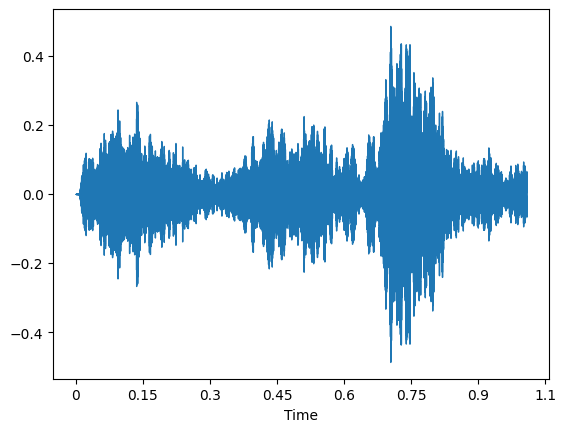

In [8]:
filename='./audio/fold2/4201-3-3-0.wav'  # select a random oneplt.figure(figsize=(14,5))
data,sample_rate=librosa.load(filename)
librosa.display.waveshow(data,sr=sample_rate)
ipd.Audio(filename)

In [9]:
metadata=pd.read_csv('audio/UrbanSound8K.csv')
metadata.head(10)

,slice_file_name,fsID,start,end,salience,fold,classID,class
0,100032-3-0-0.wav,100032,0.000000,0.317551,1,5,3,dog_bark
1,100263-2-0-117.wav,100263,58.500000,62.500000,1,5,2,children_playing
2,100263-2-0-121.wav,100263,60.500000,64.500000,1,5,2,children_playing
3,100263-2-0-126.wav,100263,63.000000,67.000000,1,5,2,children_playing
4,100263-2-0-137.wav,100263,68.500000,72.500000,1,5,2,children_playing
5,100263-2-0-143.wav,100263,71.500000,75.500000,1,5,2,children_playing
6,100263-2-0-161.wav,100263,80.500000,84.500000,1,5,2,children_playing
7,100263-2-0-3.wav,100263,1.500000,5.500000,1,5,2,children_playing
8,100263-2-0-36.wav,100263,18.000000,22.000000,1,5,2,children_playing
9,100648-1-0-0.wav,100648,4.823402,5.471927,2,10,1,car_horn


In [10]:
### Check whether the dataset is imbalanced
metadata['class'].value_counts()

class
dog_bark            1000
children_playing    1000
air_conditioner     1000
street_music        1000
jackhammer          1000
engine_idling       1000
drilling            1000
siren                929
car_horn             429
gun_shot             374
Name: count, dtype: int64

In [11]:
dat1, sampling_rate1 = librosa.load('./audio/fold5/100032-3-0-0.wav')
dat2, sampling_rate2 = librosa.load('./audio/fold5/100263-2-0-117.wav')

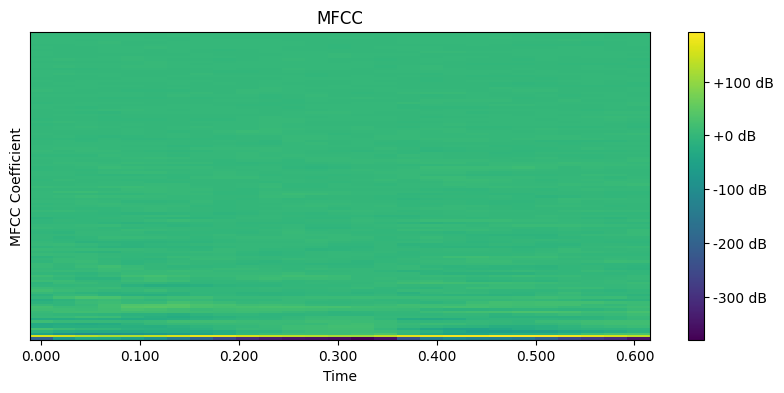

In [27]:
import librosa
import librosa.display
import matplotlib.pyplot as plt

def plot_mfcc(audio_path):
    # Load the audio file
    y, sr = librosa.load(audio_path)

    # Extract MFCC features
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=128)

    # Plot MFCCs
    plt.figure(figsize=(10, 4))
    librosa.display.specshow(mfccs, x_axis='time', cmap='viridis')
    plt.colorbar(format='%+2.0f dB')
    plt.title('MFCC')
    plt.xlabel('Time')
    plt.ylabel('MFCC Coefficient')
    plt.show()

# Example usage
audio_file_path = './audio/fold6/4910-3-0-0.wav'
plot_mfcc(audio_file_path)

In [14]:
import librosa#random sample
filename='./audio/fold6/4910-3-0-0.wav'
audio_data,sample_rate=librosa.load(filename)
mfccs=librosa.feature.mfcc(y=audio_data,sr=sample_rate, n_mfcc=128)
print(mfccs.shape)
print(mfccs)

(128, 27)
[[-2.0414842e+02 -7.3352737e+01 -3.1521664e+01 ... -2.8262634e+02
  -3.0813928e+02 -3.4986868e+02]
 [ 1.6085672e+02  1.5085524e+02  1.3205711e+02 ...  1.7034235e+02
   1.5520447e+02  1.3646313e+02]
 [-4.7794083e+01 -8.1008530e+01 -9.6134056e+01 ...  1.7801125e+01
   2.7814308e+01  3.0667643e+01]
 ...
 [ 1.8539858e-01  1.7941580e+00  5.5091381e-01 ...  7.5651646e-01
   2.4906158e-02  5.3799915e-01]
 [-7.3656654e-01 -1.1901817e+00 -9.0071106e-01 ...  4.8907185e-01
  -1.5518656e+00 -1.2077427e+00]
 [ 8.4392548e-01  3.3357239e-01 -2.3057556e-01 ...  4.3945312e-01
   1.3983688e+00  2.5930862e+00]]


Text(0.5, 1.0, 'Linear-frequency power spectrogram')

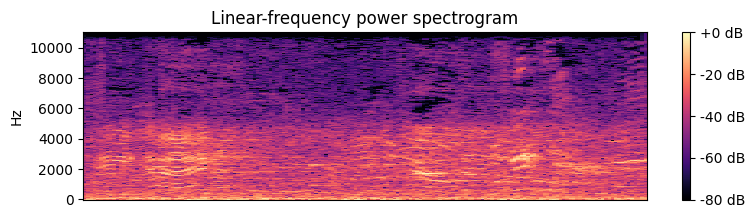

In [13]:
plt.figure(figsize=(20, 10))
D = librosa.amplitude_to_db(np.abs(librosa.stft(dat2)), ref=np.max)
plt.subplot(4, 2, 1)
librosa.display.specshow(D, y_axis='linear')
plt.colorbar(format='%+2.0f dB')
plt.title('Linear-frequency power spectrogram')

Text(0.5, 1.0, 'Linear-frequency power spectrogram')

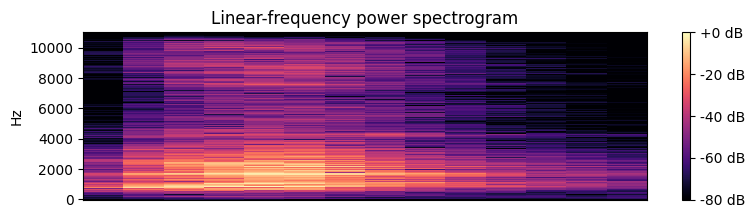

In [12]:
plt.figure(figsize=(20, 10))
D = librosa.amplitude_to_db(np.abs(librosa.stft(dat1)), ref=np.max)
plt.subplot(4, 2, 1)
librosa.display.specshow(D, y_axis='linear')
plt.colorbar(format='%+2.0f dB')
plt.title('Linear-frequency power spectrogram')

In [10]:
### Let's read a sample audio using librosaimport librosa
librosa_audio_data,librosa_sample_rate=librosa.load(filename)
print(librosa_audio_data)

[-1.0477379e-08  9.3132257e-10  9.3132257e-10 ...  5.2534759e-02
 -5.0471686e-03 -2.0513367e-02]


In [20]:
import numpy as np
from tqdm import tqdm
import os

def features_extractor(file):
    audio, sample_rate = librosa.load(file_name) 
    mfccs_features = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=128)
    mfccs_scaled_features = np.mean(mfccs_features.T,axis=0)    
    return mfccs_scaled_features

# Now we iterate through every audio file and extract features 
# using Mel-Frequency Cepstral Coefficients

audio_dataset_path='audio/'
extracted_features=[]
metadata = pd.read_csv('./audio/UrbanSound8K.csv')
for index_num,row in tqdm(metadata.iterrows()):
    file_name = os.path.join(os.path.abspath(audio_dataset_path),'fold'+str(row["fold"])+'/',str(row["slice_file_name"]))
    
    final_class_labels=row["class"]
    
    data=features_extractor(file_name)
    extracted_features.append([data,final_class_labels])
    
# converting extracted_features to Pandas dataframe
extracted_features_df=pd.DataFrame(extracted_features,columns=['feature','class'])
extracted_features_df.head()

3554it [01:21, 42.06it/s]/home/ubuntu/MyProject/env/lib/python3.10/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1323
  warnings.warn(
8324it [03:16, 56.14it/s]/home/ubuntu/MyProject/env/lib/python3.10/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1103
  warnings.warn(
/home/ubuntu/MyProject/env/lib/python3.10/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1523
  warnings.warn(
8732it [03:25, 42.39it/s]


,feature,class
0,"[-211.93698, 62.58121, -122.813156, -60.745293...",dog_bark
1,"[-417.0052, 99.336624, -42.995583, 51.073326, ...",children_playing
2,"[-452.39316, 112.36253, -37.57807, 43.195866, ...",children_playing
3,"[-406.47922, 91.1966, -25.043556, 42.78452, 11...",children_playing
4,"[-439.63873, 103.86223, -42.658783, 50.690285,...",children_playing


In [29]:
### Split the dataset into independent and dependent dataset
X=np.array(extracted_features_df['feature'].tolist())
y=np.array(extracted_features_df['class'].tolist())
print(X.shape)

(8732, 128)


In [31]:
# Label Encoder
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder
labelencoder=LabelEncoder()
y=to_categorical(labelencoder.fit_transform(y))
print(y)

2025-05-02 18:29:13.214846: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-05-02 18:29:13.220120: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-05-02 18:29:13.232541: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1746210553.251400    3634 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746210553.256790    3634 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1746210553.271560    3634 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linkin

[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 1. ... 0. 0. 0.]
 [0. 0. 1. ... 0. 0. 0.]
 ...
 [0. 1. 0. ... 0. 0. 0.]
 [0. 1. 0. ... 0. 0. 0.]
 [0. 1. 0. ... 0. 0. 0.]]


In [32]:
### Train Test Split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=0)
print(X_train)
print(X_train.shape) #(6985, 128)
print(X_test.shape)  #(1747, 128)
print(y_train.shape) #(6985, 10)
print(y_test.shape)  #(1747, 10)

[[-1.24484680e+02  1.03169846e+02 -1.33165455e+01 ... -9.90453303e-01
  -9.43154037e-01 -1.02599645e+00]
 [-5.13921928e+00  7.90478210e+01  4.16248989e+00 ... -3.82960051e-01
  -8.50546658e-02 -2.49319136e-01]
 [-4.03939552e+01 -1.31092958e+01 -7.20987606e+00 ... -9.23266172e-01
  -1.03576042e-01  6.51953161e-01]
 ...
 [-4.26655701e+02  9.15513382e+01  4.19170284e+00 ...  4.15096909e-01
   2.18663603e-01  2.13547856e-01]
 [-1.37251968e+02  1.24268539e+02 -2.15997734e+01 ...  8.00883248e-02
   1.33612096e-01  2.86800683e-01]
 [-4.18389374e+02  2.06862305e+02  7.23461866e+00 ... -1.40962983e-02
  -6.32517561e-02 -1.06617615e-01]]
(6985, 128)
(1747, 128)
(6985, 10)
(1747, 10)


In [35]:
import pandas as pd
import numpy as np

pd.plotting.register_matplotlib_converters()
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.model_selection import GridSearchCV

from sklearn.preprocessing import MinMaxScaler


In [36]:
# Libraries for Classification and building Models

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, Flatten, Dense, MaxPool2D, Dropout
from tensorflow.keras.utils import to_categorical 

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

In [40]:
# Project Specific Libraries

import os
import librosa
import librosa.display
import glob 
import skimage

In [41]:
X_train = X_train.reshape(6985, 16, 8, 1)
X_test = X_test.reshape(1747, 16, 8, 1)

In [42]:
input_dim = (16, 8, 1)

In [43]:
model = Sequential()

In [44]:
model.add(Conv2D(64, (3, 3), padding = "same", activation = "tanh", input_shape = input_dim))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Conv2D(128, (3, 3), padding = "same", activation = "tanh"))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Dropout(0.1))
model.add(Flatten())
model.add(Dense(1024, activation = "tanh"))
model.add(Dense(10, activation = "softmax"))

/home/ubuntu/MyProject/env/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-05-02 18:41:03.332527: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [45]:
model.compile(optimizer = 'adam', loss = 'categorical_crossentropy', metrics = ['accuracy'])


In [47]:
model.fit(X_train, y_train, epochs = 90, batch_size = 50, validation_data = (X_test, y_test))


Epoch 1/90
140/140 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.4567 - loss: 1.6437 - val_accuracy: 0.7670 - val_loss: 0.7238
Epoch 2/90
140/140 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.7934 - loss: 0.5976 - val_accuracy: 0.8105 - val_loss: 0.5789
Epoch 3/90
140/140 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.8668 - loss: 0.3924 - val_accuracy: 0.8392 - val_loss: 0.4600
Epoch 4/90
140/140 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.8964 - loss: 0.2962 - val_accuracy: 0.8558 - val_loss: 0.4545
Epoch 5/90
140/140 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.9152 - loss: 0.2570 - val_accuracy: 0.8666 - val_loss: 0.4709
Epoch 6/90
140/140 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.9254 - loss: 0.2192 - val_accuracy: 0.8500 - val_loss: 0.4977
Epoch 7/90
140/140 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.9423 - loss: 0.1647 - val_accuracy: 0.8781 - val_loss: 0.4947
Epoch 8/90
140/140 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.9557 - loss: 0.1267 - val_accu

In [48]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 16, 8, 64)      │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 8, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 8, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 4, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │        10,250 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,403,040 (12.98 MB)

 Trainable params: 1,134,346 (4.33 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,268,694 (8.65 MB)

In [49]:
predictions = model.predict(X_test)
score = model.evaluate(X_test, y_test)
print(score)

55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8841 - loss: 0.9057
[0.8261630535125732, 0.8935317397117615]


In [50]:
preds = np.argmax(predictions, axis = 1)

In [52]:
df_result = pd.DataFrame(preds)
df_result.to_csv("UrbanSound8kResults.csv")